# Task 3: Domain Generalization


In [ ]:
import hashlib, json, math, random, shutil, subprocess, sys, zipfile
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from tqdm.auto import tqdm
from IPython.display import display

SEED=6304
DOMAINS=('photo','art_painting','cartoon')
CLASSES=('dog','elephant','giraffe','guitar','horse','house','person')
STRENGTHS=(0.1,1.,10.)
TASK2=Path('/content/drive/MyDrive/ATML_PA1/Task2_PACS_stabilized/results')
OUT=Path('/content/drive/MyDrive/ATML_PA1/Task3_PACS/results')
OUT.mkdir(parents=True,exist_ok=True)
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
assert DEVICE=='cuda','Choose a Colab GPU runtime.'
def seed_all(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
seed_all(SEED)
torch.backends.cudnn.benchmark=False
torch.backends.cudnn.deterministic=True
assert all((TASK2/p).is_file() for p in (
    'imagenet_initial.pt','source_only_erm.pt','source_only.pt',
    'splits/pacs_sketch_seed6304.json','task3_settings_locked_before_target_labels.json',
    'config.json','task2_summary.csv')),'Task 2 source checkpoint, split, config, or lock missing.'
lock=json.loads((TASK2/'task3_settings_locked_before_target_labels.json').read_text())
t2config=json.loads((TASK2/'config.json').read_text())
assert lock['seed']==SEED and tuple(lock['sources'])==DOMAINS and lock['unseen_target']=='sketch'
assert lock['dan_dg_main_lambda']==1 and lock['dan_dg_study_lambdas']==[0.1,1,10]
assert lock['sam_main_rho']==0.05 and lock['lr']==1e-4 and lock['weight_decay']==1e-4
assert t2config['global_grad_clip_norm']==1.0
assert hashlib.sha256((TASK2/'source_only.pt').read_bytes()).digest()==hashlib.sha256((TASK2/'source_only_erm.pt').read_bytes()).digest()
config={**lock,'results_dir':str(OUT),'erm_sha256':hashlib.sha256((TASK2/'source_only_erm.pt').read_bytes()).hexdigest(),
        'original_task3_lock':str(TASK2/'task3_settings_locked_before_target_labels.json'),
        'provenance_clarification':'Use shared global gradient clip 1.0 documented in the earlier Task 2 config; the original Task 3 lock is preserved.'}
config_path=OUT/'config.json'
if config_path.exists():
    assert json.loads(config_path.read_text())==config,'Task 3 configuration changed between runs.'
else:config_path.write_text(json.dumps(config,indent=2))
print('Device:',torch.cuda.get_device_name(0))
print('Original ERM checkpoint:',TASK2/'source_only_erm.pt')
print('Task 3 output:',OUT)


Mounted at /content/drive
Device: NVIDIA A100-SXM4-40GB
Original ERM checkpoint: /content/drive/MyDrive/ATML_PA1/Task2_PACS_stabilized/results/source_only_erm.pt
Task 3 output: /content/drive/MyDrive/ATML_PA1/Task3_PACS/results


## 2. Dataset and Source Splits

In [ ]:
HF_REPO='Azeez577/PACS'
HF_REVISION='46a0a83'
HF_SHA256='42bf567f1ed8a01d522e47e4a677e2a3149577bbd6fcbb38bedfdd73cb59e147'
assert t2config['dataset_sha256']==HF_SHA256
extracted=Path('/content/PACS_extracted')
if not (extracted/'PACS').is_dir():
    archive=Path('/content/PACS.zip')
    if not archive.is_file():
        subprocess.run([sys.executable,'-m','pip','install','-q','huggingface_hub'],check=True)
        from huggingface_hub import hf_hub_download
        archive=Path(hf_hub_download(repo_id=HF_REPO,repo_type='dataset',
                                     filename='PACS.zip',revision=HF_REVISION,local_dir='/content'))
    assert zipfile.is_zipfile(archive),'PACS archive missing or damaged.'
    digest=hashlib.sha256()
    with archive.open('rb') as stream:
        for chunk in iter(lambda:stream.read(8*1024*1024),b''):digest.update(chunk)
    assert digest.hexdigest()==HF_SHA256,'PACS archive differs from Task 2.'
    extracted.mkdir(exist_ok=True)
    with zipfile.ZipFile(archive) as z:
        assert z.testzip() is None
        for info in z.infolist():
            assert (extracted/info.filename).resolve().is_relative_to(extracted.resolve()),'Unsafe archive member.'
        z.extractall(extracted)
ROOT=extracted/'PACS'
assert all((ROOT/d).is_dir() for d in DOMAINS),'Expected Task 2 PACS source directories.'
split_file=TASK2/'splits/pacs_sketch_seed6304.json'
splits=json.loads(split_file.read_text())
assert set(splits)==set(DOMAINS)
extensions={'.jpg','.jpeg','.png','.bmp','.webp'}
for d in DOMAINS:
    found={str(p.relative_to(ROOT)) for p in (ROOT/d).rglob('*')
           if p.is_file() and p.suffix.lower() in extensions}
    train=set(splits[d]['train']); val=set(splits[d]['val'])
    assert not train&val and train|val==found,(d,'Task 2 split/data mismatch')
    assert all(Path(p).parts[0]==d and Path(p).parent.name.lower() in CLASSES for p in found)
    print(d,'train',len(train),'validation',len(val))

weights=ResNet18_Weights.IMAGENET1K_V1
mean,std=weights.transforms().mean,weights.transforms().std
train_tf=transforms.Compose([transforms.Resize((256,256)),transforms.RandomCrop(224),
                             transforms.RandomHorizontalFlip(),transforms.ToTensor(),
                             transforms.Normalize(mean,std)])
eval_tf=transforms.Compose([transforms.Resize((256,256)),transforms.CenterCrop(224),
                            transforms.ToTensor(),transforms.Normalize(mean,std)])
class Images(Dataset):
    def __init__(self,paths,transform):self.paths=list(paths);self.transform=transform
    def __len__(self):return len(self.paths)
    def __getitem__(self,i):
        path=self.paths[i]
        with Image.open(ROOT/path) as im:x=self.transform(im.convert('RGB'))
        return x,CLASSES.index(Path(path).parent.name.lower())
source_train={d:Images(splits[d]['train'],train_tf) for d in DOMAINS}
source_val={d:Images(splits[d]['val'],eval_tf) for d in DOMAINS}
def loader(ds,batch,shuffle=False,seed=SEED,drop_last=False):
    return DataLoader(ds,batch_size=batch,shuffle=shuffle,drop_last=drop_last,
                      num_workers=2,pin_memory=True,persistent_workers=False,
                      generator=torch.Generator().manual_seed(seed))
def epoch_loaders(epoch):
    return {d:loader(source_train[d],8,True,SEED+1000*epoch+i,True)
            for i,d in enumerate(DOMAINS)}
def forever(dl):
    while True:yield from dl
class Net(nn.Module):
    def __init__(self):
        super().__init__();self.backbone=resnet18(weights=weights)
        self.backbone.fc=nn.Identity();self.classifier=nn.Linear(512,7)
    def forward(self,x):
        f=self.backbone(x)
        return f,self.classifier(f)
def freeze_bn_stats(net):
    for m in net.modules():
        if isinstance(m,nn.modules.batchnorm._BatchNorm):m.eval()
def initial_net():
    seed_all(SEED)
    net=Net().to(DEVICE)
    net.load_state_dict(torch.load(TASK2/'imagenet_initial.pt',map_location=DEVICE,weights_only=True))
    net.train();freeze_bn_stats(net)
    return net
erm_checkpoint=torch.load(TASK2/'source_only_erm.pt',map_location=DEVICE,weights_only=True)
assert erm_checkpoint['seed']==SEED and erm_checkpoint['method']=='Source-only'
print('Reused ERM selected at Task 2 epoch',erm_checkpoint['epoch'])


PACS.zip: reconstructing file:   0%|          |  0.00B /  184MB            

PACS.zip: downloading bytes:           |  0.00B            

photo train 1336 validation 334
art_painting train 1638 validation 410
cartoon train 1875 validation 469
Reused ERM selected at Task 2 epoch 3


## 3. Training Objectives

In [ ]:
def mmd_rbf(a,b):
    combined=torch.cat([a,b],0)
    sq=torch.cdist(combined,combined,p=2).square()
    with torch.no_grad():
        upper=sq.triu(diagonal=1)
        values=upper[upper>0]
        median=values.median().clamp_min(1e-8) if len(values) else sq.new_tensor(1.)
    kernel=sum(torch.exp(-sq/(2*scale*median)) for scale in (0.5,1.,2.))
    n=len(a)
    return kernel[:n,:n].mean()+kernel[n:,n:].mean()-2*kernel[:n,n:].mean()

def source_batch(its):
    pairs=[next(its[d]) for d in DOMAINS]
    xs,ys=zip(*pairs)
    return torch.cat(xs).to(DEVICE,non_blocking=True),torch.cat(ys).to(DEVICE,non_blocking=True)

@torch.inference_mode()
def predict(net,ds):
    net.eval();true=[];pred=[]
    for x,y in loader(ds,64):
        _,z=net(x.to(DEVICE,non_blocking=True))
        true.extend(y.numpy());pred.extend(z.argmax(1).cpu().numpy())
    return np.asarray(true),np.asarray(pred)

def source_metrics(net):
    results={}
    for d in DOMAINS:
        y,p=predict(net,source_val[d])
        results[d]={'accuracy':accuracy_score(y,p),
                    'macro_f1':f1_score(y,p,labels=range(7),average='macro',zero_division=0)}
    return results

def sam_update(net,opt,x,y,params,rho=0.05):
    opt.zero_grad(set_to_none=True)
    f,z=net(x);first=F.cross_entropy(z,y)
    first.backward()
    with torch.no_grad():
        gnorm=torch.linalg.vector_norm(torch.stack([p.grad.norm(2) for p in params if p.grad is not None]))
        assert bool(torch.isfinite(gnorm))
        scale=rho/gnorm.clamp_min(1e-12)
        perturb={p:scale*p.grad.detach().clone() for p in params if p.grad is not None}
        for p,eps in perturb.items():p.add_(eps)
    try:
        opt.zero_grad(set_to_none=True)
        _,z_pert=net(x);second=F.cross_entropy(z_pert,y)
        assert bool(torch.isfinite(second))
        second.backward()
    finally:
        with torch.no_grad():
            for p,eps in perturb.items():p.sub_(eps)
    grad=torch.nn.utils.clip_grad_norm_(params,1.0,error_if_nonfinite=True)
    opt.step()
    return float(first.detach()),float(grad),float(f.detach().norm(dim=1).median())

def train(name,strength=0.):
    safe=name.lower().replace(' ','_').replace('.','p').replace('-','_')
    checkpoint=OUT/f'{safe}.pt';history_file=OUT/f'{safe}_history.csv'
    done=OUT/f'{safe}_done.json'
    if done.is_file() and checkpoint.is_file() and history_file.is_file():
        print(name,'completed; using saved source-selected checkpoint')
        return
    net=initial_net();params=list(net.parameters())
    opt=torch.optim.AdamW(params,lr=1e-4,weight_decay=1e-4)
    steps=max(math.ceil(len(source_train[d])/8) for d in DOMAINS)
    bn=[(m,m.running_mean.clone(),m.running_var.clone()) for m in net.modules()
        if isinstance(m,nn.modules.batchnorm._BatchNorm)]
    best=-float('inf');stale=0;rows=[]
    for epoch in range(1,31):
        net.train();freeze_bn_stats(net)
        src=epoch_loaders(epoch);its={d:forever(src[d]) for d in DOMAINS}
        totals={'classification':0.,'mmd':0.,'median_feature_norm':0.,
                'max_gradient_before_clip':0.}
        for _ in tqdm(range(steps),desc=f'{name} epoch {epoch}',leave=False):
            x,y=source_batch(its)
            if name=='SAM':
                cls,grad,feature_norm=sam_update(net,opt,x,y,params,rho=0.05)
                mmd=0.
            else:
                f,z=net(x);loss_cls=F.cross_entropy(z,y)
                a,b,c=f.split(8,dim=0)
                loss_mmd=(mmd_rbf(a,b)+mmd_rbf(a,c)+mmd_rbf(b,c))/3
                loss=loss_cls+strength*loss_mmd
                assert bool(torch.isfinite(loss)),f'Nonfinite loss: {name} epoch {epoch}'
                opt.zero_grad(set_to_none=True);loss.backward()
                grad=float(torch.nn.utils.clip_grad_norm_(params,1.0,error_if_nonfinite=True))
                opt.step()
                cls=float(loss_cls.detach());mmd=float(loss_mmd.detach())
                feature_norm=float(f.detach().norm(dim=1).median())
            assert math.isfinite(feature_norm) and feature_norm<1e5, f'Unstable {name} feature norm.'
            totals['classification']+=cls/steps;totals['mmd']+=mmd/steps
            totals['median_feature_norm']+=feature_norm/steps
            totals['max_gradient_before_clip']=max(totals['max_gradient_before_clip'],grad)
        assert all(torch.equal(m.running_mean,mu) and torch.equal(m.running_var,var)
                   for m,mu,var in bn),'BatchNorm running statistics changed.'
        scores=source_metrics(net)
        mean_f1=float(np.mean([scores[d]['macro_f1'] for d in DOMAINS]))
        row={'method':name,'epoch':epoch,'mean_source_macro_f1':mean_f1,**totals,
             **{f'{d}_{k}':v for d in DOMAINS for k,v in scores[d].items()}}
        rows.append(row);pd.DataFrame(rows).to_csv(history_file,index=False)
        print(f'{name}: epoch {epoch} | mean source F1 {mean_f1:.4f} | '
              f'CE {totals["classification"]:.4f} | MMD {totals["mmd"]:.4f} | '
              f'feature norm {totals["median_feature_norm"]:.1f} | '
              f'max unclipped grad {totals["max_gradient_before_clip"]:.1f}')
        if mean_f1>best+1e-12:
            best=mean_f1;stale=0
            torch.save({'model':net.state_dict(),'method':name,'strength':strength,
                        'epoch':epoch,'source_validation':scores,'seed':SEED},checkpoint)
        else:stale+=1
        if stale>=5:break
    done.write_text(json.dumps({'epochs_ran':len(rows),'best_source_macro_f1':best}))
    print(name,'selected at source epoch',torch.load(checkpoint,map_location='cpu',weights_only=True)['epoch'])

for lam in STRENGTHS:train(f'DAN-DG {lam:g}',lam)
train('SAM')
print('Source-only ERM was reused; four new runs completed. No Sketch image opened.')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 216MB/s]


DAN-DG 0.1 epoch 1:   0%|          | 0/235 [00:00<?, ?it/s]

DAN-DG 0.1: epoch 1 | mean source F1 0.8891 | CE 0.4843 | MMD 0.4071 | feature norm 41.1 | max unclipped grad 33.4


DAN-DG 0.1 epoch 2:   0%|          | 0/235 [00:00<?, ?it/s]

...

SAM: epoch 21 | mean source F1 0.9430 | CE 0.0023 | MMD 0.0000 | feature norm 58.6 | max unclipped grad 13.1


SAM epoch 22:   0%|          | 0/235 [00:00<?, ?it/s]

SAM: epoch 22 | mean source F1 0.9563 | CE 0.0018 | MMD 0.0000 | feature norm 55.9 | max unclipped grad 21.3


SAM epoch 23:   0%|          | 0/235 [00:00<?, ?it/s]

SAM: epoch 23 | mean source F1 0.9454 | CE 0.0008 | MMD 0.0000 | feature norm 60.4 | max unclipped grad 15.5
SAM selected at source epoch 18
Source-only ERM was reused; four new runs completed. No Sketch image opened.


## 4. Source Validation and Training Curves

,method,selected_epoch,photo_accuracy,photo_macro_f1,art_painting_accuracy,art_painting_macro_f1,cartoon_accuracy,cartoon_macro_f1,mean_source_accuracy,worst_source_accuracy,worst_accuracy_domain,mean_source_macro_f1,worst_source_macro_f1,worst_macro_f1_domain
0,ERM,3,0.9521,0.9454,0.9000,0.8959,0.9467,0.9492,0.9329,0.9000,art_painting,0.9301,0.8959,art_painting
1,DAN-DG 0.1,9,0.9701,0.9640,0.9098,0.9114,0.9531,0.9563,0.9443,0.9098,art_painting,0.9439,0.9114,art_painting
2,DAN-DG 1,1,0.2575,0.0585,0.2195,0.0514,0.1727,0.0421,0.2166,0.1727,cartoon,0.0507,0.0421,cartoon
3,DAN-DG 10,2,0.2575,0.0585,0.2195,0.0514,0.1727,0.0421,0.2166,0.1727,cartoon,0.0507,0.0421,cartoon
4,SAM,18,0.9820,0.9792,0.9293,0.9304,0.9659,0.9672,0.9591,0.9293,art_painting,0.9589,0.9304,art_painting


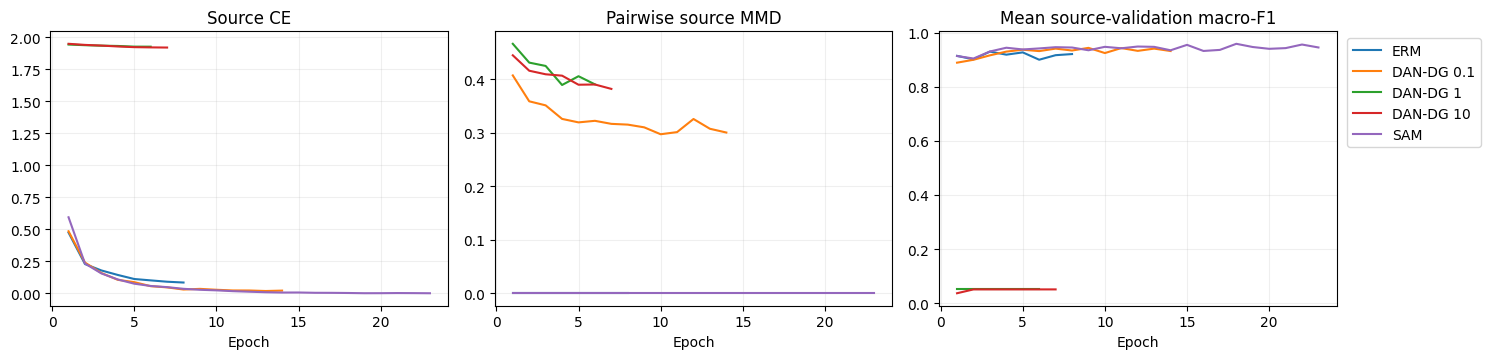

In [ ]:
def key(name):return name.lower().replace(' ','_').replace('.','p').replace('-','_')
NAMES=('ERM','DAN-DG 0.1','DAN-DG 1','DAN-DG 10','SAM')
def selected(name):
    path=TASK2/'source_only_erm.pt' if name=='ERM' else OUT/f'{key(name)}.pt'
    ck=torch.load(path,map_location=DEVICE,weights_only=True)
    net=Net().to(DEVICE);net.load_state_dict(ck['model']);net.eval()
    return net,ck
source_rows=[]
for name in NAMES:
    net,ck=selected(name)
    scores=source_metrics(net)
    row={'method':name,'selected_epoch':ck['epoch']}
    for d in DOMAINS:
        for metric in ('accuracy','macro_f1'):row[f'{d}_{metric}']=scores[d][metric]
    for metric in ('accuracy','macro_f1'):
        vals=[scores[d][metric] for d in DOMAINS]
        row[f'mean_source_{metric}']=float(np.mean(vals))
        row[f'worst_source_{metric}']=float(np.min(vals))
        row[f'worst_{metric}_domain']=DOMAINS[int(np.argmin(vals))]
    source_rows.append(row)
source_table=pd.DataFrame(source_rows)
source_table.to_csv(OUT/'source_validation.csv',index=False)
display(source_table.round(4))

history_parts=[]
erm_hist=pd.read_csv(TASK2/'source_only_history.csv').copy()
erm_hist['method']='ERM';erm_hist['mmd']=0.;history_parts.append(erm_hist)
for name in NAMES[1:]:history_parts.append(pd.read_csv(OUT/f'{key(name)}_history.csv'))
histories=pd.concat(history_parts,ignore_index=True)
fig,axes=plt.subplots(1,3,figsize=(15,3.7))
for name,frame in histories.groupby('method',sort=False):
    for ax,column in zip(axes,('classification','mmd','mean_source_macro_f1')):
        ax.plot(frame.epoch,frame[column],label=name)
for ax,title in zip(axes,('Source CE','Pairwise source MMD','Mean source-validation macro-F1')):
    ax.set_title(title);ax.set_xlabel('Epoch');ax.grid(alpha=.2)
axes[-1].legend(bbox_to_anchor=(1.01,1),loc='upper left')
fig.tight_layout();fig.savefig(OUT/'source_training_curves.png',dpi=170,bbox_inches='tight');plt.show()


## 5. Source-Only Experiments

In [ ]:
rng=np.random.default_rng(SEED)
probe_paths={d:source_val[d].paths for d in DOMAINS}
probe_n=min(map(len,probe_paths.values()))
probe_idx={d:rng.choice(len(probe_paths[d]),size=probe_n,replace=False) for d in DOMAINS}
fixed_rng=np.random.default_rng(SEED)
fixed_idx={d:fixed_rng.choice(len(source_val[d]),32,replace=False) for d in DOMAINS}
fixed_images=[];fixed_labels=[]
for d in DOMAINS:
    for i in fixed_idx[d]:
        x,y=source_val[d][int(i)];fixed_images.append(x);fixed_labels.append(y)
fixed_x=torch.stack(fixed_images).to(DEVICE)
fixed_y=torch.tensor(fixed_labels,dtype=torch.long,device=DEVICE)
assert len(fixed_y)==96

@torch.inference_mode()
def source_features(net,domain,indices):
    net.eval();ds=Images([probe_paths[domain][int(i)] for i in indices],eval_tf)
    chunks=[]
    for x,_ in loader(ds,64):
        f,_=net(x.to(DEVICE,non_blocking=True));chunks.append(f.cpu().numpy())
    return np.concatenate(chunks)

def sharpness(net):
    net.eval();params=[p for p in net.parameters() if p.requires_grad]
    net.zero_grad(set_to_none=True)
    _,logits=net(fixed_x);base=F.cross_entropy(logits,fixed_y)
    base.backward()
    with torch.no_grad():
        gnorm=torch.linalg.vector_norm(torch.stack([p.grad.norm(2) for p in params if p.grad is not None]))
        assert bool(torch.isfinite(gnorm))
        eps={p:0.05*p.grad.detach().clone()/gnorm.clamp_min(1e-12)
             for p in params if p.grad is not None}
        for p,e in eps.items():p.add_(e)
    try:
        with torch.no_grad():
            _,perturbed_logits=net(fixed_x)
            perturbed=F.cross_entropy(perturbed_logits,fixed_y)
            delta=float((perturbed-base.detach()).cpu())
    finally:
        with torch.no_grad():
            for p,e in eps.items():p.sub_(e)
        net.zero_grad(set_to_none=True)
    return delta

diagnostic_rows=[]
for name in NAMES:
    net,_=selected(name)
    X=np.concatenate([source_features(net,d,probe_idx[d]) for d in DOMAINS])
    domains=np.concatenate([np.full(probe_n,i,dtype=int) for i,_ in enumerate(DOMAINS)])
    tr,te=train_test_split(np.arange(len(domains)),test_size=.3,random_state=SEED,stratify=domains)
    probe=LogisticRegression(C=1.,max_iter=2000,random_state=SEED)
    probe.fit(X[tr],domains[tr])
    diagnostic_rows.append({'method':name,'validation_examples_per_domain':probe_n,
                            'source_domain_separability':accuracy_score(domains[te],probe.predict(X[te])),
                            'sharpness_increase':sharpness(net)})
diagnostics=pd.DataFrame(diagnostic_rows)
diagnostics.to_csv(OUT/'source_diagnostics.csv',index=False)
display(diagnostics.round(5))
print('Source models and diagnostics fixed. Sketch has not been opened by this notebook.')


,method,validation_examples_per_domain,source_domain_separability,sharpness_increase
0,ERM,334,0.87708,0.26476
1,DAN-DG 0.1,334,0.70100,0.18888
2,DAN-DG 1,334,0.36213,0.03065
3,DAN-DG 10,334,0.33223,0.02359
4,SAM,334,0.84385,0.19972


Source models and diagnostics fixed. Sketch has not been opened by this notebook.


## 6. Final Sketch Evaluation

In [ ]:
assert all((OUT/f'{key(name)}_done.json').is_file() and (OUT/f'{key(name)}.pt').is_file()
           for name in NAMES[1:]),'Complete all Task 3 source-only training before final evaluation.'
assert (OUT/'source_validation.csv').is_file() and (OUT/'source_diagnostics.csv').is_file()
target_dir=ROOT/'sketch'
assert target_dir.is_dir(),'Expected Sketch only at the final evaluation stage.'
target_paths=sorted(str(p.relative_to(ROOT)) for p in target_dir.rglob('*')
                    if p.is_file() and p.suffix.lower() in extensions)
assert len(target_paths)==t2config['dataset_domain_counts']['sketch']==3929
target=Images(target_paths,eval_tf)
result_rows=[];class_rows=[];cm_rows=[];prediction_rows=[]
for name in NAMES:
    net,_=selected(name)
    true,pred=predict(net,target)
    assert len(true)==len(target_paths) and set(np.unique(true))==set(range(7))
    result_rows.append({'method':name,'sketch_accuracy':accuracy_score(true,pred),
                        'sketch_macro_f1':f1_score(true,pred,labels=range(7),average='macro',zero_division=0)})
    matrix=confusion_matrix(true,pred,labels=range(7))
    for i,actual in enumerate(CLASSES):
        sel=true==i
        class_rows.append({'method':name,'class':actual,'n':int(sel.sum()),
                           'accuracy':float(np.mean(pred[sel]==i))})
        for j,predicted in enumerate(CLASSES):
            cm_rows.append({'method':name,'actual':actual,'predicted':predicted,
                            'n':int(matrix[i,j])})
    prediction_rows.extend({'method':name,'target_file':path,'true':CLASSES[int(y)],
                            'predicted':CLASSES[int(p)]}
                           for path,y,p in zip(target_paths,true,pred))
result_frame=pd.DataFrame(result_rows)
result=source_table.merge(diagnostics.drop(columns=['validation_examples_per_domain']),on='method').merge(result_frame,on='method')
erm_acc=result.loc[result.method=='ERM','sketch_accuracy'].iloc[0]
result['sketch_change_vs_erm_pp']=100*(result.sketch_accuracy-erm_acc)
original=pd.read_csv(TASK2/'task2_summary.csv')
t2_erm=original.loc[original.method=='Source-only','target_accuracy'].iloc[0]
assert abs(erm_acc-t2_erm)<1e-12,'Reused ERM differs from Task 2 target evaluation.'
result.to_csv(OUT/'task3_summary.csv',index=False)
per_class=pd.DataFrame(class_rows)
erm_class=per_class[per_class.method=='ERM'].set_index('class')['accuracy']
per_class['change_vs_erm_pp']=per_class.apply(lambda r:100*(r.accuracy-erm_class[r['class']]),axis=1)
per_class.to_csv(OUT/'sketch_per_class.csv',index=False)
confusions=pd.DataFrame(cm_rows);confusions.to_csv(OUT/'sketch_confusions.csv',index=False)
predictions=pd.DataFrame(prediction_rows);predictions.to_csv(OUT/'sketch_predictions.csv',index=False)
print('Main method comparison:')
display(result[result.method.isin(['ERM','DAN-DG 1','SAM'])].round(4))
print('Locked DAN-DG strength study (main λ=1):')
study=result[result.method.str.startswith('DAN-DG')][['method','mean_source_macro_f1',
    'worst_source_macro_f1','source_domain_separability','sharpness_increase',
    'sketch_accuracy','sketch_macro_f1','sketch_change_vs_erm_pp']]
study.to_csv(OUT/'dan_dg_strength_study.csv',index=False)
display(study.round(4))
print('Sketch class-level changes (percentage points):')
display(per_class.pivot(index='class',columns='method',values='change_vs_erm_pp').round(1))


Main method comparison:


,method,selected_epoch,photo_accuracy,photo_macro_f1,art_painting_accuracy,art_painting_macro_f1,cartoon_accuracy,cartoon_macro_f1,mean_source_accuracy,worst_source_accuracy,worst_accuracy_domain,mean_source_macro_f1,worst_source_macro_f1,worst_macro_f1_domain,source_domain_separability,sharpness_increase,sketch_accuracy,sketch_macro_f1,sketch_change_vs_erm_pp
0,ERM,3,0.9521,0.9454,0.9000,0.8959,0.9467,0.9492,0.9329,0.9000,art_painting,0.9301,0.8959,art_painting,0.8771,0.2648,0.6073,0.5716,0.0000
2,DAN-DG 1,1,0.2575,0.0585,0.2195,0.0514,0.1727,0.0421,0.2166,0.1727,cartoon,0.0507,0.0421,cartoon,0.3621,0.0307,0.0407,0.0112,-56.6556
4,SAM,18,0.9820,0.9792,0.9293,0.9304,0.9659,0.9672,0.9591,0.9293,art_painting,0.9589,0.9304,art_painting,0.8439,0.1997,0.7371,0.7569,12.9804


Locked DAN-DG strength study (main λ=1):


,method,mean_source_macro_f1,worst_source_macro_f1,source_domain_separability,sharpness_increase,sketch_accuracy,sketch_macro_f1,sketch_change_vs_erm_pp
1,DAN-DG 0.1,0.9439,0.9114,0.7010,0.1889,0.5750,0.5735,-3.2324
2,DAN-DG 1,0.0507,0.0421,0.3621,0.0307,0.0407,0.0112,-56.6556
3,DAN-DG 10,0.0507,0.0421,0.3322,0.0236,0.0407,0.0112,-56.6556


Sketch class-level changes (percentage points):


method,DAN-DG 0.1,DAN-DG 1,DAN-DG 10,ERM,SAM
class,,,,,
dog,29.0,-11.3,-11.3,0.0,56.6
elephant,-2.6,-98.1,-98.1,0.0,-12.4
giraffe,13.0,-63.3,-63.3,0.0,-3.6
guitar,5.3,-66.0,-66.0,0.0,30.9
horse,-57.7,-74.0,-74.0,0.0,-15.3
house,-1.3,-71.2,-71.2,0.0,25.0
person,6.3,78.8,78.8,0.0,68.1


## 7. Class Failures and Task 2 Comparison


 DAN-DG 1 largest decreases: [('elephant', -98.1), ('horse', -74.0)] | largest increases: [('person', 78.8)]
  elephant [('person', 740)]
  horse [('person', 816)]
  person []

 SAM largest decreases: [('horse', -15.3), ('elephant', -12.4)] | largest increases: [('dog', 56.6), ('person', 68.1)]
  horse [('dog', 228), ('elephant', 69)]
  elephant [('dog', 93), ('person', 10)]
  dog [('elephant', 143), ('person', 62)]
  person [('elephant', 7), ('giraffe', 6)]


,task,method,sketch_accuracy,sketch_macro_f1
0,Task 2 DAN (target available unlabeled),DAN 1,0.6485,0.5771
1,Task 3 DAN-DG (no target access),DAN-DG 1,0.0407,0.0112


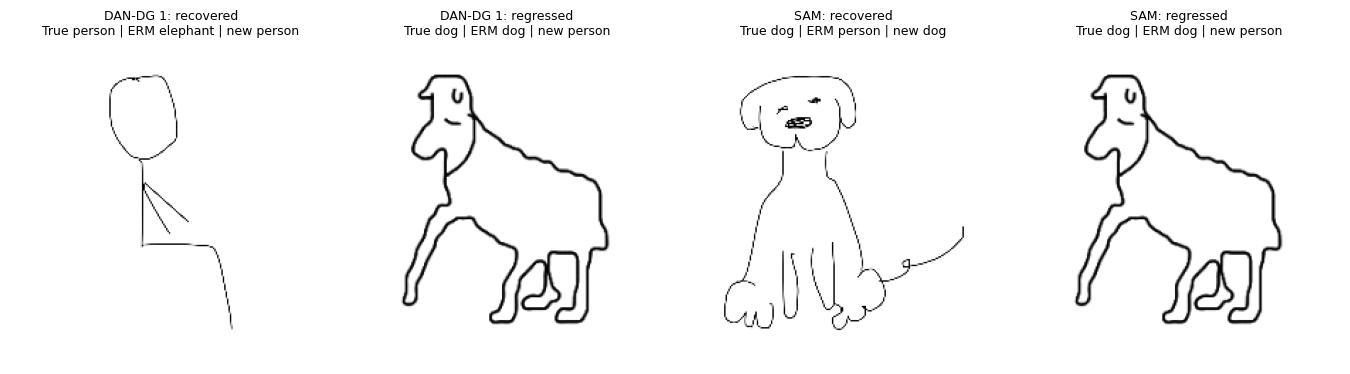

Task 3 checkpoints, splits reference, diagnostics, figures, and tables saved: /content/drive/MyDrive/ATML_PA1/Task3_PACS/results


In [ ]:
for name in ('DAN-DG 1','SAM'):
    changes=per_class[per_class.method==name].sort_values('change_vs_erm_pp')
    negative=changes[changes.change_vs_erm_pp<0].head(2)
    positive=changes[changes.change_vs_erm_pp>0].tail(2)
    print('\n',name,'largest decreases:',list(zip(negative['class'],negative.change_vs_erm_pp.round(1))),
          '| largest increases:',list(zip(positive['class'],positive.change_vs_erm_pp.round(1))))
    for row in pd.concat([negative,positive]).itertuples():
        errors=confusions[(confusions.method==name)&(confusions.actual==row._2)&
                          (confusions.predicted!=row._2)&(confusions.n>0)]
        errors=errors.sort_values('n',ascending=False).head(2)
        print(' ',row._2,[(r.predicted,int(r.n)) for r in errors.itertuples()])

comparisons=pd.DataFrame([
    {'task':'Task 2 DAN (target available unlabeled)','method':'DAN 1',
     'sketch_accuracy':float(original.loc[original.method=='DAN 1','target_accuracy'].iloc[0]),
     'sketch_macro_f1':float(original.loc[original.method=='DAN 1','target_macro_f1'].iloc[0])},
    {'task':'Task 3 DAN-DG (no target access)','method':'DAN-DG 1',
     'sketch_accuracy':float(result.loc[result.method=='DAN-DG 1','sketch_accuracy'].iloc[0]),
     'sketch_macro_f1':float(result.loc[result.method=='DAN-DG 1','sketch_macro_f1'].iloc[0])},
])
comparisons.to_csv(OUT/'task2_dan_vs_task3_dan_dg.csv',index=False)
display(comparisons.round(4))

ref=predictions[predictions.method=='ERM'].set_index('target_file')
examples=[]
for name in ('DAN-DG 1','SAM'):
    curr=predictions[predictions.method==name].set_index('target_file')
    for label,mask in [('recovered',(ref.true!=ref.predicted)&(curr.true==curr.predicted)),
                       ('regressed',(ref.true==ref.predicted)&(curr.true!=curr.predicted))]:
        paths=sorted(ref.index[mask])
        if paths:
            path=paths[0]
            examples.append((name,label,path,curr.loc[path,'true'],
                             ref.loc[path,'predicted'],curr.loc[path,'predicted']))
if examples:
    fig,axes=plt.subplots(1,len(examples),figsize=(3.4*len(examples),3.7),squeeze=False)
    for ax,(name,label,path,true,erm,new) in zip(axes[0],examples):
        with Image.open(ROOT/path) as im:ax.imshow(im.convert('RGB'))
        ax.set_title(f'{name}: {label}\nTrue {true} | ERM {erm} | new {new}',fontsize=9)
        ax.axis('off')
    fig.tight_layout();fig.savefig(OUT/'sketch_failure_examples.png',dpi=170,bbox_inches='tight');plt.show()
pd.DataFrame(examples,columns=['method','category','target_file','true',
                              'erm_prediction','method_prediction']).to_csv(OUT/'sketch_failure_examples.csv',index=False)
print('Task 3 checkpoints, splits reference, diagnostics, figures, and tables saved:',OUT)
